# Suture Quality Pipeline

End-to-end demonstration of the current project: dataset audit, frame extraction, auto-annotation, frozen dataset, and the geometry baselines (RandomForest + TinyUNet).

Everything here reuses the code in `scripts/` and the artifacts in `data/`. Heavy steps (ffmpeg extraction, full training) are already done and committed; cells below load their outputs and re-run lightweight versions so you can see the work live.

- Plan: `Docs/suture-quality-pipeline-plan.md`
- Auto-annotation decision: `Docs/adr/0005-auto-annotation-pilot.md`, `Docs/adr/0006-local-json-annotation-store.md`


In [1]:
import sys
from pathlib import Path
import csv

import cv2
import numpy as np
import matplotlib.pyplot as plt

REPO = Path(".").resolve()
if not (REPO / "data").exists() and (REPO.parent / "data").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

with (REPO / "data/manifests/dataset_manifest.csv").open(encoding="utf-8") as handle:
    rows = [row for row in csv.DictReader(handle)]
selected = [r for r in rows if r["status"] == "selected"]
print(f"Total frames in frozen manifest: {len(rows)}")
print(f"Selected frames: {len(selected)}")
print(f"Annotated frames: {sum(1 for r in selected if r['annotated'] == 'True')}")
print("Split counts:", {s: sum(1 for r in selected if r['split'] == s) for s in ('train', 'val', 'test')})

Total frames in frozen manifest: 21408
Selected frames: 19145
Annotated frames: 3815
Split counts: {'train': 10766, 'val': 2900, 'test': 5479}


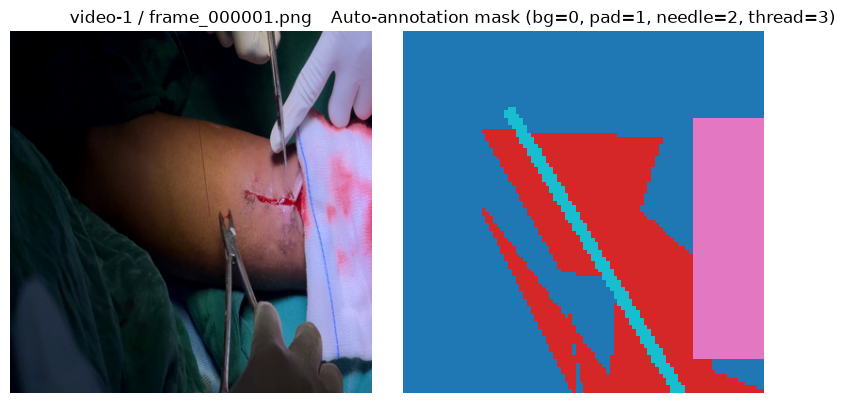

Shapes detected: [('wound_pad', 'polygon'), ('needle', 'box'), ('thread', 'polyline')]


In [2]:
from scripts.geometry_baseline import build_class_mask, load_annotation, GRID_SIZE

row = next(r for r in selected if r["annotated"] == "True" and r["split"] == "train")
frame_name = Path(row["output_path"]).name
frame = cv2.imread(str(REPO / "data/frames" / row["video_id"] / frame_name))
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
shapes = load_annotation(row["video_id"], frame_name, REPO / "data/annotations")
mask = build_class_mask(shapes, GRID_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(frame)
axes[0].set_title(f"{row['video_id']} / {frame_name}")
axes[0].axis("off")
axes[1].imshow(mask, cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("Auto-annotation mask (bg=0, pad=1, needle=2, thread=3)")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print("Shapes detected:", [(s['label'], s['kind']) for s in shapes])

## Note on heavy steps

- **Extraction** (ffmpeg 5 fps + quality filter): `uv run python -m scripts.extract_frames` -> `data/frames/` and `data/manifests/frame_manifest.csv` (already run).
- **Auto-annotation**: `uv run python -m scripts.auto_annotate --video <id>` -> `data/annotations/<id>.json` + preview sheets (already run for all 9 videos).
- **Freeze**: `uv run python -m scripts.freeze_dataset` -> `data/manifests/dataset_manifest.csv` + `reports/dataset-freeze.md` (already run).

The cells below re-run lightweight versions of the two baselines so you can watch them train live.


In [3]:
import torch
from scripts.deep_geometry import TinyUNet, mask_to_tensor, mean_iou, class_weights, load_frame_tensor
from scripts.geometry_baseline import build_class_mask, load_annotation, GRID_SIZE, class_iou, pixel_accuracy

torch.manual_seed(0)
train_rows = [r for r in selected if r["split"] == "train" and r["annotated"] == "True"][:60]
val_rows = [r for r in selected if r["split"] == "val" and r["annotated"] == "True"][:20]

def inputs(frame_rows):
    xs, ys = [], []
    for r in frame_rows:
        name = Path(r["output_path"]).name
        xs.append(load_frame_tensor(r["video_id"], name, REPO / "data/frames"))
        ys.append(build_class_mask(load_annotation(r["video_id"], name, REPO / "data/annotations"), GRID_SIZE))
    return xs, ys

train_x, train_y = inputs(train_rows)
val_x, val_y = inputs(val_rows)
model = TinyUNet()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights(train_y))

for epoch in range(4):
    model.train()
    for i in range(0, len(train_x), 8):
        batch = torch.stack(train_x[i : i + 8])
        target = torch.stack([mask_to_tensor(m) for m in train_y[i : i + 8]])
        opt.zero_grad()
        loss_fn(model(batch), target).backward()
        opt.step()
    model.eval()
    preds = [model(x.unsqueeze(0)).argmax(1)[0].numpy() for x in val_x]
    print(f"epoch {epoch + 1}: val mean IoU = {mean_iou(preds, val_y):.4f}")

epoch 1: val mean IoU = 0.3012


epoch 2: val mean IoU = 0.3417


epoch 3: val mean IoU = 0.3904


epoch 4: val mean IoU = 0.3794


In [4]:
test_rows = [r for r in selected if r["split"] == "test" and r["annotated"] == "True"][:30]
model.eval()
truths, preds = [], []
for r in test_rows:
    name = Path(r["output_path"]).name
    x = load_frame_tensor(r["video_id"], name, REPO / "data/frames")
    with torch.no_grad():
        pred = model(x.unsqueeze(0)).argmax(1)[0].numpy()
    truth = build_class_mask(load_annotation(r["video_id"], name, REPO / "data/annotations"), GRID_SIZE)
    truths.append(truth)
    preds.append(pred)

truth_all, pred_all = np.stack(truths), np.stack(preds)
print(f"Pixel accuracy: {pixel_accuracy(pred_all, truth_all):.4f}")
for c, name in enumerate(("background", "wound_pad", "needle", "thread")):
    print(f"  {name:12s} IoU = {class_iou(pred_all, truth_all, c):.4f}")

Pixel accuracy: 0.6229
  background   IoU = 0.6313
  wound_pad    IoU = 0.0127
  needle       IoU = 0.0000
  thread       IoU = 0.0058


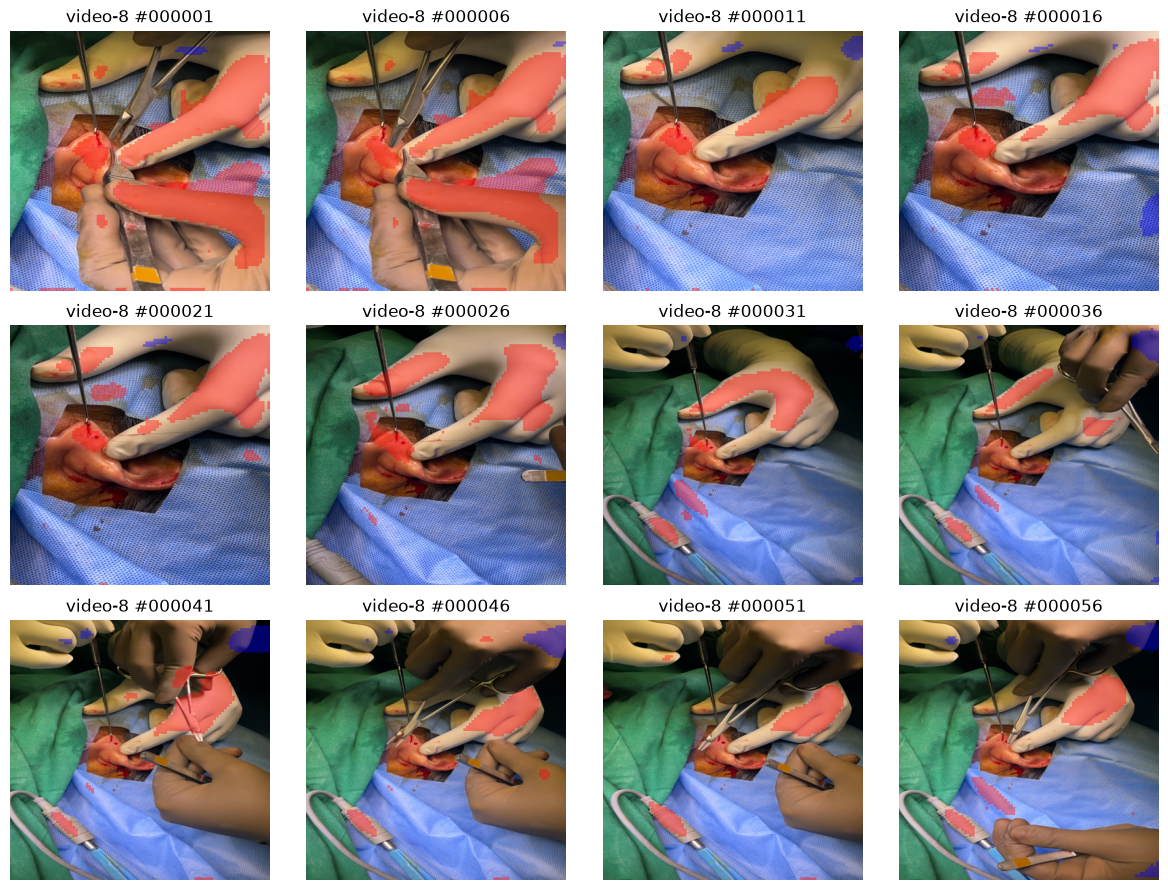

In [5]:
# Preview: predicted masks overlaid on test frames
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
colors = {1: (255, 0, 0), 2: (0, 255, 0), 3: (0, 0, 255)}
for ax, r, p in zip(axes.ravel(), test_rows[:12], preds[:12]):
    name = Path(r["output_path"]).name
    frame = cv2.imread(str(REPO / "data/frames" / r["video_id"] / name))
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    up = cv2.resize(p.astype(np.uint8), (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_NEAREST)
    overlay = frame.copy()
    for cid, color in colors.items():
        overlay[up == cid] = color
    ax.imshow(cv2.addWeighted(frame, 0.6, overlay, 0.4, 0))
    ax.set_title(f"{r['video_id']} #{Path(name).stem[-6:]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Interpreting these numbers

- Labels are **AI-generated and unreviewed** (ADR-0005) - the metrics measure agreement with those labels, not clinical truth.
- The TinyUNet outperforms the RandomForest per-pixel baseline on all foreground classes but is trained here on a tiny subset for notebook speed. Full runs: `reports/geometry-baseline.md` and `reports/geometry-deep.md`.
- Accuracy-improvement research (libraries, preprocessing, noise-tolerant training) lands in `Docs/research/accuracy-improvements.md`.

Next steps: apply the researched improvements, then stitch events, quality regression, and the feedback-video renderer.
